# Example: Compute and Analyze the Covariance Matrix for Our Dataset
The lecture introduced a covariance matrix to describe how the growth rates of different firms vary together. How do we estimate this matrix from historical share prices, and what can it tell us about holding firms together in a portfolio?

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * **Compute the empirical covariance matrix:** Construct and center a matrix of historical growth rates, then use a matrix product to calculate the sample covariance.
> * **Convert and check the covariance estimate:** Obtain the covariance rate needed by the geometric Brownian motion model, verify the sample covariance against a library function, and compare the resulting volatilities with our L4b estimates.
> * **Interpret covariance and correlation:** Use a correlation heatmap and a scatter plot for two firms to interpret their linear relationship and discuss its effect on portfolio variance.

In this example, we compute the covariance matrix for our historical equity dataset and check its connection to the volatility estimates from L4b. We then visualize correlations across a subset of firms and examine the growth rates of two selected firms in more detail.

Let's get started!

___


## Setup, Data, and Prerequisites
First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates [`Include.jl`](Include.jl) in the notebook's global scope. The setup file activates the course project, defines local paths, loads the packages used here, and includes local helper code.

Let's set up our code environment:

In [1]:
# Load the course environment, market-data functions, and local helpers -
include(joinpath(@__DIR__, "Include.jl")); # resolve the setup path from this notebook's folder

  Activating 

project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


See the [Julia documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/) for the functions and types used here.

### Data
Our training dataset contains daily price records for stocks in the [S&P 500](https://en.wikipedia.org/wiki/S%26P_500), along with several exchange-traded funds and volatility products, from January 3, 2014 through December 31, 2024. Each record includes open, high, low, and close prices, as well as the volume-weighted average price that we use to compute growth rates.

Let's load the data by calling [the MyTrainingMarketDataSet() function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet). We store the ticker-keyed dictionary in `original_dataset::Dict{String,DataFrame}`:

In [2]:
# Load training histories; each dictionary entry is one ticker's price DataFrame -
original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"]; # extract prices from the dataset bundle

Some tickers have shorter histories, for example because they were listed after the sample began. We use `AAPL`, which has a complete record, to set the number of trading days required for inclusion. Let's save this count in `maximum_number_trading_days::Int64`:

In [3]:
# Use a complete price history as the required observation count -
maximum_number_trading_days = original_dataset["AAPL"] |> nrow; # price rows, before taking differences

Now, let's collect the tickers with `maximum_number_trading_days` records. In this dataset, these complete records share the same trading dates, so each row of our growth-rate matrix will compare firms over the same time interval. We store the cleaned dataset $\mathcal{D}$ in `dataset::Dict{String,DataFrame}`:

In [4]:
dataset = let

    # Initialize a ticker-to-price-table dictionary -
    dataset = Dict{String, DataFrame}(); # store retained histories without changing their rows

    # Keep histories with the same length as AAPL.
    # Their dates are aligned in this dataset; equal lengths alone do not establish alignment.
    for (ticker, data) ∈ original_dataset 
        if (nrow(data) == maximum_number_trading_days) # retain tickers with complete histories
            dataset[ticker] = data;
        end
    end
    dataset; # return the dictionary from this local let block
end;

Next, let's sort the retained ticker symbols alphabetically and store them in `list_of_tickers::Array{String,1}`. This order will determine the columns of our growth-rate matrix and the rows and columns of our covariance matrix:

In [5]:
# Fix the asset order used by all vectors and matrices -
list_of_tickers = keys(dataset) |> collect |> sort; # column i of G and row/column i of covariance use this order

Next, let's load the [saved parameter table](data/SAGBM-Parameters-Fall-2025.csv) for the volatility comparison with [the L4b parameters example](../../week-4/L4b/CHEME-5660-L4b-Example-Parameters-SAGBM-Fall-2026.ipynb). The table uses the same 2014 to 2024 training period. The legacy `drift` column contains the fitted mean growth rate $\hat{\mu}_g$ (inverse years), and `volatility` contains $\hat{\sigma}$ (inverse square-root years). We store the table in `parameters_df::DataFrame` and look up firms by ticker when making the comparison:

In [6]:
parameters_df = let

    # Load the saved L4b estimates for a same-data volatility check -
    # The legacy drift column stores mean log growth, not arithmetic GBM drift.
    df = CSV.read(joinpath(_PATH_TO_DATA,"SAGBM-Parameters-Fall-2025.csv"), DataFrame);
    df; # return the table; later comparisons match tickers rather than row numbers
end;

The first five rows show the column names and a sample of the estimates:

In [7]:
# Display the saved parameter columns and a few fitted values -
first(parameters_df, 5) # preview only; keep the full table for ticker lookups

Row,ticker,drift,t,lower_bound_drift,upper_bound_drift,volatility
,String7,Float64,Float64,Float64,Float64,Float64
1,A,0.147468,1.96,0.145642,0.149294,0.231467
2,AAL,-0.141294,1.96,-0.144465,-0.138123,0.455075
3,AAP,-0.0481021,1.96,-0.0523949,-0.0438093,0.342624
4,AAPL,0.24271,1.96,0.240519,0.2449,0.234516
5,ABBV,0.116,1.96,0.114452,0.117547,0.242982


Finally, let's use 252 trading days per year, so the time step between successive daily observations is $\Delta t=1/252$ years. We will use this time step to convert the growth-rate covariance to the covariance rate required by the model:

In [8]:
# Set the time convention used in both growth rates and covariance-rate scaling -
trading_days_per_year = 252; # number of trading days in a year
Δt = (1/trading_days_per_year); # time step (1 trading day, in years)

___

## Task 1: Compute the Empirical Covariance Matrix
In this task, we compute the empirical growth-rate covariance matrix $\hat{\mathbf{\Sigma}}_g$ for our cleaned dataset $\mathcal{D}$ and convert it to the covariance rate $\hat{\mathbf{C}}$ needed by the model.

For firm $i$, let $S^{(i)}_{k-1}$ and $S^{(i)}_k$ be successive volume-weighted average prices. The growth rate over the interval of length $\Delta t$ years is given by:
$$
g_k^{(i)}=\frac{1}{\Delta t}\ln\!\left(\frac{S_k^{(i)}}{S_{k-1}^{(i)}}\right).
$$
With $N\geq2$ time intervals and $M$ firms, we arrange these rates in $\mathbf{G}\in\mathbb{R}^{N\times M}$. Each row holds all firms' growth rates over the same interval, and each column holds one firm's time series. The entries have units of inverse years.

[The log_growth_matrix(...) function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix) constructs this matrix in the order of `list_of_tickers`. We pass the time step from setup and store the result in `G::Array{Float64,2}`:

In [9]:
# Convert successive VWAP prices to log(S_k/S_{k-1})/Δt -
G = log_growth_matrix(dataset, list_of_tickers; Δt=Δt); # N intervals × M firms, entries in year⁻¹
size(G) # one fewer interval than price rows; columns follow list_of_tickers

(2766, 424)

The matrix has one fewer row than the number of price observations because each growth rate uses two successive prices. Next, let's compute each firm's sample-mean growth rate by averaging its column of $\mathbf{G}$. We store the vector of sample means $\mathbf{g}^{\prime}\in\mathbb{R}^{M}$ in `g_mean::Array{Float64,1}`:

In [10]:
# Average over observation rows, separately for each firm -
g_mean = mean(G, dims=1) |> vec; # convert the 1 × M row to an M-vector of sample means (year⁻¹)

Covariance measures how firms' growth rates vary together relative to their own means. Let's subtract each firm's sample mean from its column to form the centered data matrix:
$$
\tilde{\mathbf{G}}=\mathbf{G}-\mathbf{1}\,\mathbf{g}^{\prime\top},
$$
where $\mathbf{1}\in\mathbb{R}^{N}$ is a vector of ones.

> __Outer product:__ The product $\mathbf{1}\,\mathbf{g}^{\prime\top}$ repeats the row of sample means $N$ times. More generally, the [outer product](https://en.wikipedia.org/wiki/Outer_product) of vectors $\mathbf{a}\in\mathbb{R}^{N}$ and $\mathbf{b}\in\mathbb{R}^{M}$ is the $N\times M$ matrix $\mathbf{a}\mathbf{b}^{\top}$ with entries $(\mathbf{a}\mathbf{b}^{\top})_{kj}=a_k b_j$.

In Julia, `ones(N)*g_mean'` forms this outer product. Subtracting it from `G` gives the same result as broadcasting `G .- g_mean'`. We store the centered data in `G_centered::Array{Float64,2}`:

In [11]:
G_centered = let 
    N, M = size(G); # N observed growth intervals and M firms
    ones_vector = ones(N); # repeat the row of M means at each of the N intervals
    G̃ = G .- ones_vector*g_mean'; # subtract the outer product 1 g′ᵀ
    @assert isapprox(G̃, G .- g_mean'; atol=1e-12) # same as broadcasting the row of means
    G̃ # return centered observations, with approximately zero column means
end;

Finally, let's form $\tilde{\mathbf{G}}^{\top}\tilde{\mathbf{G}}$. Each entry adds the products of two firms' deviations over the same time intervals. Dividing by $N-1$ gives the sample covariance. From the lecture, multiplying this covariance by $\Delta t$ gives the covariance rate needed by the model:
$$
\begin{align*}
\hat{\mathbf{\Sigma}}_g &= \frac{1}{N-1}\tilde{\mathbf{G}}^{\top}\tilde{\mathbf{G}},\\
\hat{\mathbf{C}} &= \Delta t\,\hat{\mathbf{\Sigma}}_g.
\end{align*}
$$
The growth-rate covariance has units of inverse years squared, while the covariance rate has units of inverse years. We store these matrices in `Σ̂_g::Array{Float64,2}` and `Ĉ::Array{Float64,2}`:

In [12]:
Σ̂_g, Ĉ = let
   # Pair same-interval deviations and correct for the estimated column means -
   (N, M) = size(G_centered) # N observations; the covariance has M rows and columns
   Σ_g = (1/(N-1)) * (G_centered' * G_centered); # divide by N-1 for sample covariance, units: year⁻²
   C = Δt*Σ_g; # GBM covariance rate, units: 1/year
   (Σ_g, C) # tuple order matches the two variables assigned outside the let block
end;
size(Σ̂_g) # confirm one row and column per retained firm

(424, 424)

The square $M\times M$ result contains one covariance for every pair of firms. Its diagonal entries are the firms' growth-rate variances, and its off-diagonal entries describe their pairwise covariances. The ticker order established during setup identifies the firm at each row and column.

___

## Task 2: Check the Covariance Estimate
In this task, we check our covariance calculation against the library implementation and use the diagonal of $\hat{\mathbf{C}}$ to recover the volatility estimates from L4b. We then consider an informal comparison with the implied volatility quoted in the options market.

### Compare with the Library Calculation
[The cov(...) function](https://docs.julialang.org/en/v1/stdlib/Statistics/#Statistics.cov) computes the sample covariance of the columns of `G`, using the same $N-1$ normalization as our matrix calculation. Let's store this result in `Σ_g_builtin` and compare it with $\hat{\mathbf{\Sigma}}_g$. Both matrices are growth-rate covariances, before multiplication by $\Delta t$:


In [14]:
# Check the matrix construction against Statistics.cov using the same observations -
Σ_g_builtin = let
    cov(G, dims=1); # columns are variables; default correction also divides by N-1
end;
# Allow roundoff; this checks implementation agreement, not prediction accuracy.
@assert isapprox(Σ̂_g, Σ_g_builtin, rtol=1e-10)
println(
    "Maximum absolute difference between our Σ̂_g and cov(G): ",
    maximum(abs.(Σ̂_g .- Σ_g_builtin))
)

Maximum absolute difference between our Σ̂_g and cov(G): 0.0


The maximum absolute difference should be zero or small enough to be explained by floating-point arithmetic. Agreement checks our implementation of the centered-data formula; both calculations use the same observations.

### Recover the L4b Volatility Estimate
The library comparison checks the matrix calculation. How can we also check the conversion to the covariance rate? Recall that the diagonal of $\hat{\mathbf{C}}$ contains the squared volatility estimates. Taking the square root gives:
$$
\hat{\sigma}_i=\sqrt{\hat{C}_{ii}}
=\sqrt{\Delta t}\sqrt{\hat{\Sigma}_{g,ii}}.
$$
This is the same growth-rate standard deviation times $\sqrt{\Delta t}$ that we used in [the L4b parameters example](../../week-4/L4b/CHEME-5660-L4b-Example-Parameters-SAGBM-Fall-2026.ipynb). Let's select a firm and look up its ticker in both `list_of_tickers` and `parameters_df`, so we compare the same firm even if their row orders differ:


In [15]:
let
    # Look up the same firm in the covariance matrix and saved parameter table.
    ticker_to_check = "AMD"; # change to any ticker present in both sources
    i = findfirst(==(ticker_to_check), list_of_tickers); # covariance row/column
    j = findfirst(==(ticker_to_check), parameters_df.ticker); # independently locate its CSV row
    σ_ii = sqrt(Ĉ[i,i]); # square root converts year⁻¹ covariance rate to year⁻¹ᐟ² volatility

    # Retrieve the previously computed volatility.
    σ_ii_previous = parameters_df[j, :volatility];

    # Compare the two estimates.
    difference = abs(σ_ii - σ_ii_previous); # compare unrounded estimates, then round only for display
    println(
        "$(ticker_to_check): sqrt(Ĉ_ii) = $(round(σ_ii, digits=6)), ",
        "L4b volatility = $(round(σ_ii_previous, digits=6)), ",
        "abs(difference) = $(round(difference, sigdigits=3))"
    )
end

AMD: sqrt(Ĉ_ii) = 0.474283, L4b volatility = 0.474283, abs(difference) = 1.67e-16


The two volatility estimates should agree to floating-point precision because they use the same price observations, time step, and sample-variance normalization. A small difference confirms that the covariance-rate calculation reproduces the saved historical estimate. You can repeat the check by changing `ticker_to_check` to another retained ticker.

### Compare with Market Implied Volatility
There is also an informal comparison we can make in class. Let's look at the implied volatility quoted for an option on the selected firm using a broker screen. This notebook contains no options data.

> __Implied Volatility:__ The [implied volatility](https://en.wikipedia.org/wiki/Implied_volatility) is the volatility that makes an option-pricing model, such as the [Black-Scholes model](https://en.wikipedia.org/wiki/Black%E2%80%93Scholes_model) or the [binomial model](https://en.wikipedia.org/wiki/Binomial_options_pricing_model), reproduce the market price of an option. It is inferred from that price for the option's remaining life.

Implied volatility is annualized and has the same units as $\hat{\sigma}_i$ (inverse square-root years), so we can compare the two directly. Equivalently, the square of implied volatility is comparable in units to $\hat{C}_{ii}$, which has units of inverse years. Convert percentage quotes to decimal units before comparing them with the printed estimate.

These values need not agree. Implied volatility depends on the option maturity and reflects risk-neutral pricing, while $\hat{\sigma}_i$ is estimated from historical observations. The market comparison therefore checks units and scale; it does not validate either estimate or establish that the model will describe future prices accurately.

We have now checked the covariance calculation and its volatility scaling. Next, let's examine what the matrix tells us about the relationships between firms.

___


## Task 3: Analyze Covariance and Correlation
In this task, let's examine correlations across a subset of firms, then select two tickers and compare their covariance and correlation with a scatter plot of their growth rates.


### Visualize the Correlation Matrix
The magnitude of a covariance depends on how variable both firms' growth rates are. To compare the strength of their linear relationship, we divide their covariance by their sample standard deviations:
$$
\rho_{ij}=\frac{\hat{\Sigma}_{g,ij}}
{\sqrt{\hat{\Sigma}_{g,ii}\hat{\Sigma}_{g,jj}}}.
$$
Correlation is dimensionless and lies between $-1$ and $1$ when both variances are positive. The same correlation results from $\hat{\mathbf{C}}$, because the common factor $\Delta t$ cancels in this ratio.

Let's display the first 40 firms in alphabetical order, or all retained firms if there are fewer than 40. In the code, `σ_g` holds their growth-rate standard deviations and `ρ_sub` holds their correlations. The row and column labels identify each pair:


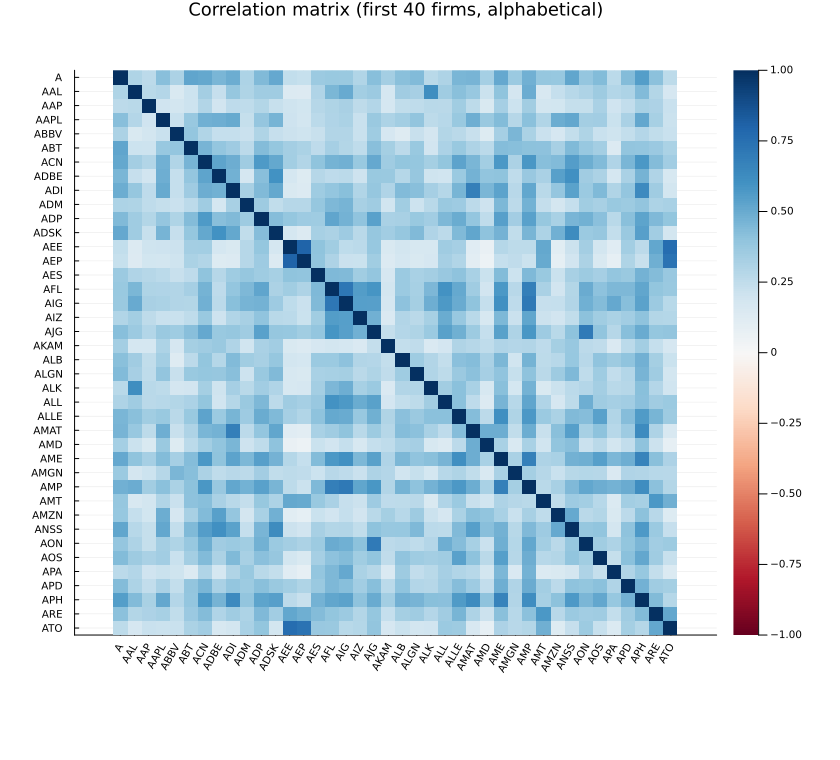

In [13]:
let
    # Select a labeled subset in the established ticker order.
    n_show = min(40, length(list_of_tickers)); # cap the display without indexing past the available firms
    tickers_to_show = list_of_tickers[1:n_show];
    Σ_sub = Σ̂_g[1:n_show, 1:n_show]; # same subset on both axes preserves pair alignment
    σ_g = sqrt.(diag(Σ_sub)); # growth-rate standard deviations
    ρ_sub = Σ_sub ./ (σ_g*σ_g'); # outer product supplies σ_i σ_j; divide each entry

    # Display dimensionless correlation on the full [-1, 1] scale -
    # yflip puts the first ticker at the top, matching ordinary matrix row order.
    heatmap(ρ_sub,
        xticks=(1:n_show, tickers_to_show),
        yticks=(1:n_show, tickers_to_show),
        xrotation=60, tickfontsize=7,
        title="Correlation matrix (first $(n_show) firms, alphabetical)",
        titlefontsize=12,
        color=:RdBu, clims=(-1,1), colorbar_ticks=(-1:0.5:1),
        aspect_ratio=:equal, yflip=true,
        colorbar_fontsize=8,
        left_margin=6Plots.mm, bottom_margin=10Plots.mm,
        right_margin=8Plots.mm, size=(840, 760))
end

Blue cells indicate positive correlation, red cells negative correlation, and white cells values near zero. The diagonal is one because each firm is perfectly correlated with itself. The matrix is symmetric, so every off-diagonal pair appears twice. Use the ticker labels to identify a pair whose relationship you would like to examine more closely.


### Compare Two Firms
Let's select two tickers from our retained dataset. They need not belong to the subset displayed in the heatmap. We store the symbols in `ticker_1::String` and `ticker_2::String`:


In [16]:
# Select the pair for the numerical comparison and scatter plot -
ticker_1 = "AMD"; # horizontal-axis firm; must be in list_of_tickers
ticker_2 = "NVDA"; # vertical-axis firm; use a different retained ticker

Next, let's find the row and column corresponding to each ticker and retrieve their growth-rate covariance from $\hat{\mathbf{\Sigma}}_g$. We use the same standardization as the heatmap to calculate their correlation:


In [17]:
let
    # Match ticker names to the covariance matrix indices -
    i = findfirst(==(ticker_1), list_of_tickers);
    j = findfirst(==(ticker_2), list_of_tickers);
    covariance_ij = Σ̂_g[i,j]; # growth-rate covariance, year⁻²
    correlation_ij = covariance_ij / sqrt(Σ̂_g[i,i]*Σ̂_g[j,j]); # dimensionless; needs positive variances
    println(
        "Growth-rate covariance between $ticker_1 and $ticker_2: ",
        "$(round(covariance_ij, digits=4)) (1/yr²)"
    )
    println(
        "Correlation between $ticker_1 and $ticker_2: ",
        round(correlation_ij, digits=4)
    )
end

Growth-rate covariance between AMD and NVDA: 27.2863 (1/yr²)
Correlation between AMD and NVDA: 0.5875


Each point in the scatter plot below represents the two firms' growth rates over the same time interval. We place `ticker_1` on the horizontal axis and `ticker_2` on the vertical axis. The red least-squares line has slope:
$$
b=\frac{\hat{\Sigma}_{g,ij}}{\hat{\Sigma}_{g,ii}}.
$$
Its intercept is $g'_j-bg'_i$, so it passes through the point $(g'_i,g'_j)$ formed by the sample means. We store these coefficients in the local `slope` and `intercept` variables:


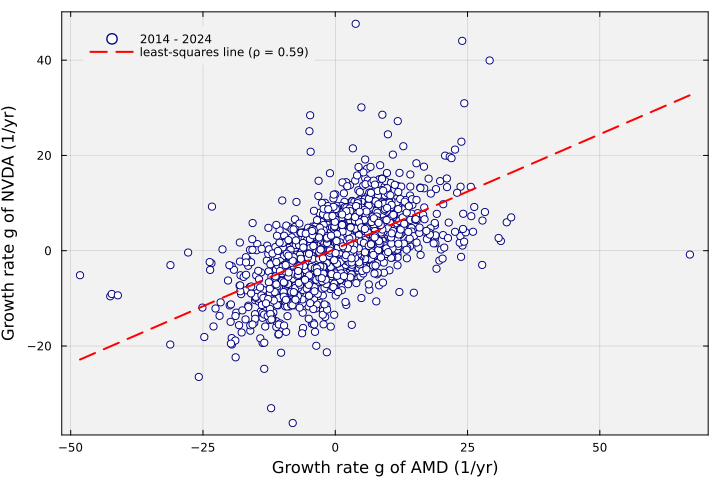

In [18]:
let
    # Retrieve growth rates over the same intervals for both firms.
    i = findfirst(==(ticker_1), list_of_tickers);
    j = findfirst(==(ticker_2), list_of_tickers);
    x = G[:,i]; # one x value per observed interval, in year⁻¹
    y = G[:,j]; # matching interval rows keep each (x, y) observation paired

    # Fit the least-squares line of y on x from the sample moments.
    slope = Σ̂_g[i,j]/Σ̂_g[i,i]; # Cov(x,y)/Var(x), for regression of y on x
    intercept = g_mean[j] - slope*g_mean[i]; # make the fitted line pass through both sample means
    ρ = Σ̂_g[i,j]/sqrt(Σ̂_g[i,i]*Σ̂_g[j,j]);
    xline = [minimum(x), maximum(x)]; # endpoints span the observed horizontal range

    # Display paired observations, then add the fitted line to the same plot -
    # plot! modifies the existing figure; it does not fit another regression.
    scatter(x, y,
        xlabel="Growth rate g of $ticker_1 (1/yr)",
        ylabel="Growth rate g of $ticker_2 (1/yr)",
        label="2014 - 2024", c=:white, msc=:navy,
        size=(720, 480))
    plot!(xline, intercept .+ slope.*xline,
        color=:red, linestyle=:dash,
        label="least-squares line (ρ = $(round(ρ, digits=2)))", lw=2)
    plot!(bg="gray95", background_color_outside="white",
        framestyle=:box, fg_legend=:transparent);
end

An upward-sloping line indicates that the firms tend to be above or below their own mean growth rates together; a downward-sloping line indicates deviations in opposite directions. The magnitude of the correlation describes the strength of this linear association. The absolute spread around the line also depends on the firms' growth-rate variability. A correlation near zero indicates little linear association, but does not establish independence.


### Connection to Portfolio Variance
Why do these relationships matter when we hold the firms together? Using the lecture's weighted-growth approximation $g_p=w_i g^{(i)}+w_j g^{(j)}$ with fixed weights, the estimated variance is given by:
$$
\widehat{\operatorname{Var}}(g_p)
=w_i^2\hat{\Sigma}_{g,ii}
+w_j^2\hat{\Sigma}_{g,jj}
+2w_iw_j\hat{\Sigma}_{g,ij}.
$$
The covariance enters through the last term. For two positive weights, a negative covariance reduces this contribution to portfolio variance, while a positive covariance increases it. If one weight is negative, the sign of the contribution reverses. The full variance also depends on both firms' variances and the sizes of the weights.

### Discussion Questions
1. How do the covariance sign, correlation, and fitted line describe the relationship between your selected firms?
2. How would changing the portfolio weights change the covariance contribution to variance?
3. Try a pair from different sectors, such as an energy firm and a technology firm. Is its correlation lower than that of your original pair?


___

## Summary
In this example, we estimated covariance from historical prices, checked its connection to the model's volatility parameters, and examined what it tells us about relationships between firms.

> __Key Takeaways:__
>
> * **Empirical covariance from historical growth rates:** We converted aligned price observations into a matrix of growth rates and subtracted each firm's sample mean. Dividing the centered-data matrix product by $N-1$ gave us the sample variances and pairwise covariances for all retained firms.
>
> * **Covariance-rate scaling and checks:** We used $\hat{\mathbf{C}}=\Delta t\,\hat{\mathbf{\Sigma}}_g$ to obtain the covariance rate required by the model. Comparing our matrix with the library calculation and recovering the L4b volatility estimates checked the construction and scaling. We also explained why market implied volatility provides an informal comparison of units and scale.
>
> * **Correlation and portfolio variance:** We used correlation to compare linear relationships across firms and examined them with a heatmap and a scatter plot with a fitted line. The two-firm portfolio variance expression showed how the covariance contribution depends on both the relationship between firms and the signs and sizes of their portfolio weights.

These estimates give us the covariance rate needed to model correlated asset prices and the growth-rate covariance needed to compare portfolio variances.

___


## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.
